In [2]:
graph = {
    '5': ['3', '7'],
    '3': ['2', '4'],
    '7': ['8'],
    '2': [],
    '4': ['8'],
    '8': []
}

visited = []  # List for visited nodes
queue = []    # Initialize a queue

def bfs(visited, graph, node):  # function for BFS
    visited.append(node)
    queue.append(node)

    while queue:  # Creating loop to visit each node
        m = queue.pop(0)
        print(m, end=" ")

        for neighbour in graph[m]:
            if neighbour not in visited:
                visited.append(neighbour)
                queue.append(neighbour)

# Driver Code
print("Following is the Breadth-First Search:")
bfs(visited, graph, '5')  # function call


Following is the Breadth-First Search:
5 3 7 2 4 8 

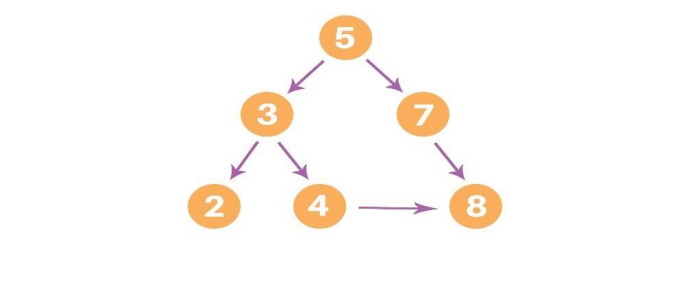

In [6]:
def printParents(node, adj, parent):
    # current node is Root, thus, has no parent
    if (parent == 0):
        print(node, "->Root")
    else:
        print(node, "->", parent)

    # Using DFS
    for cur in adj[node]:
        if (cur != parent):
            printParents(cur, adj, node)


# Function to print the children of each node
def printChildren(Root, adj):
    # Queue for the BF
    q = []

    # pushing the root
    q.append(Root)

    # visit array to keep track of nodes that have been visited
    vis = [0] * len(adj)

    while (len(q) > 0):
        node = q[0]
        q.pop(0)
        vis[node] = 1

        print(node, "-> ", end=" ")

        for cur in adj[node]:
            if (vis[cur] == 0):
                print(cur, " ", end=" ")
                q.append(cur)

        print("\n")


def printLeafNodes(Root, adj):
    for i in range(0, len(adj)):
        if (len(adj[i]) == 1 and i != Root):
            print(i, end=" ")
    print("\n")


def printDegrees(Root, adj):
    for i in range(1, len(adj)):
        print(i, ": ", end=" ")

        if (i == Root):
            print(len(adj[i]))
        else:
            print(len(adj[i]) - 1)


N = 7
Root = 1

adj = []
for i in range(0, N + 1):
    adj.append([])

adj[1].append(2)
adj[2].append(1)
adj[1].append(3)
adj[3].append(1)
adj[1].append(4)
adj[4].append(1)
adj[2].append(5)
adj[5].append(2)
adj[2].append(6)
adj[6].append(2)
adj[4].append(7)
adj[7].append(4)
# Printing the parents of each node
print("The parents of each node are:")
printParents(Root, adj, 0)
# Printing the children of each node
print("The children of each node are:")
printChildren(Root, adj)
# Printing the leaf nodes in the tree
print("The leaf nodes of the tree are:")
printLeafNodes(Root, adj)
# Printing the degrees of each node
print("The degrees of each node are:")
printDegrees(Root, adj)


The parents of each node are:
1 ->Root
2 -> 1
5 -> 2
6 -> 2
3 -> 1
4 -> 1
7 -> 4
The children of each node are:
1 ->  2   3   4   

2 ->  5   6   

3 ->  

4 ->  7   

5 ->  

6 ->  

7 ->  

The leaf nodes of the tree are:
3 5 6 7 

The degrees of each node are:
1 :  3
2 :  2
3 :  0
4 :  1
5 :  0
6 :  0
7 :  0


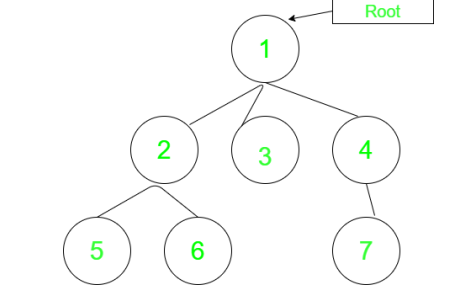

In [7]:
graph = {
    'A': ['B', 'E', 'C'],
    'B': ['A', 'E', 'D'],
    'E': ['A', 'B', 'D'],
    'C': ['A', 'F', 'G'],
    'D': ['B', 'E'],
    'F': ['C'],
    'G': ['C']
}

visited = []
queue = []

def bfs(visited, graph, node):
    visited.append(node)
    queue.append(node)

    while queue:
        m = queue.pop(0)
        print(m, end=" ")

        for neighbour in graph[m]:
            if neighbour not in visited:
                visited.append(neighbour)
                queue.append(neighbour)

print("BFS Traversal:")
bfs(visited, graph, 'A')

BFS Traversal:
A B E C D F G 

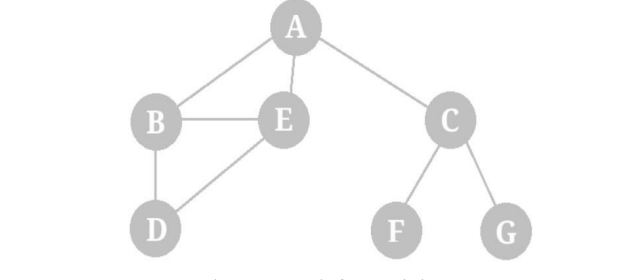

In [11]:
from collections import deque
import heapq

# Graph with weights
graph = {
    'A': [('B', 6), ('C', 9), ('E', 1)],
    'B': [('A', 6), ('D', 3), ('E', 4)],
    'C': [('A', 9), ('F', 2), ('G', 3)],
    'D': [('B', 3), ('E', 5), ('F', 7)],
    'E': [('A', 1), ('B', 4), ('D', 5), ('F', 6)],
    'F': [('C', 2), ('E', 6), ('D', 7)],
    'G': [('C', 3)]
}

# BFS (finds shortest path in terms of edges)
def bfs(graph, start, goal):
    visited = set()
    queue = deque([(start, [start])])

    while queue:
        node, path = queue.popleft()

        if node == goal:
            return path

        visited.add(node)

        for neighbor, _ in graph[node]:
            if neighbor not in visited:
                queue.append((neighbor, path + [neighbor]))

    return None

# Calculate total cost of a path
def calculate_cost(graph, path):
    cost = 0
    for i in range(len(path) - 1):
        for neighbor, weight in graph[path[i]]:
            if neighbor == path[i + 1]:
                cost += weight
                break
    return cost

# Uniform Cost Search (finds minimum cost path)
def ucs(graph, start, goal):
    pq = [(0, start, [start])]
    visited = set()

    while pq:
        cost, node, path = heapq.heappop(pq)

        if node == goal:
            return path, cost

        if node in visited:
            continue

        visited.add(node)

        for neighbor, weight in graph[node]:
            if neighbor not in visited:
                heapq.heappush(pq, (cost + weight, neighbor, path + [neighbor]))

    return None, float('inf')

# ----------- MAIN -----------
start = 'A'
goal = 'G'

# BFS result
bfs_path = bfs(graph, start, goal)
bfs_cost = calculate_cost(graph, bfs_path)

# UCS result
ucs_path, ucs_cost = ucs(graph, start, goal)

# Output
print("Start:", start, "Goal:", goal)

print("\nBFS Path:", bfs_path)
print("BFS Cost:", bfs_cost)

print("\nUCS Path:", ucs_path)
print("UCS Cost:", ucs_cost)

Start: A Goal: G

BFS Path: ['A', 'C', 'G']
BFS Cost: 12

UCS Path: ['A', 'C', 'G']
UCS Cost: 12


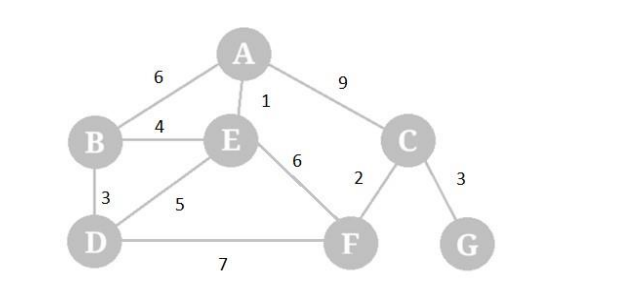

In [12]:
from collections import deque

# Graph representation based on the provided map
graph = {
    'Arad': {'Zerind': 75, 'Sibiu': 140, 'Timisoara': 118},
    'Zerind': {'Oradea': 71, 'Arad': 75},
    'Oradea': {'Zerind': 71, 'Sibiu': 151},
    'Sibiu': {'Arad': 140, 'Oradea': 151, 'Fagaras': 99, 'Rimnicu Vilcea': 80},
    'Timisoara': {'Arad': 118, 'Lugoj': 111},
    'Lugoj': {'Timisoara': 111, 'Mehadia': 70},
    'Mehadia': {'Lugoj': 70, 'Drobeta': 75},
    'Drobeta': {'Mehadia': 75, 'Craiova': 120},
    'Craiova': {'Drobeta': 120, 'Rimnicu Vilcea': 146, 'Pitesti': 138},
    'Rimnicu Vilcea': {'Sibiu': 80, 'Craiova': 146, 'Pitesti': 97},
    'Fagaras': {'Sibiu': 99, 'Bucharest': 211},
    'Pitesti': {'Rimnicu Vilcea': 97, 'Craiova': 138, 'Bucharest': 101},
    'Bucharest': {'Fagaras': 211, 'Pitesti': 101, 'Giurgiu': 90, 'Urziceni': 85}
}

def bfs_shortest_path(graph, start, goal):
    # Queue stores (current_node, path_list, total_distance)
    queue = deque([(start, [start], 0)])
    visited = set([start])

    while queue:
        (node, path, distance) = queue.popleft()

        for neighbor, weight in graph[node].items():
            if neighbor == goal:
                return path + [neighbor], distance + weight

            if neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, path + [neighbor], distance + weight))

    return None, 0

# Execute BFS
start_node = 'Arad'
goal_node = 'Bucharest'
path, total_dist = bfs_shortest_path(graph, start_node, goal_node)

print(f"BFS Path: {' -> '.join(path)}")
print(f"Total Distance: {total_dist}")

BFS Path: Arad -> Sibiu -> Fagaras -> Bucharest
Total Distance: 450


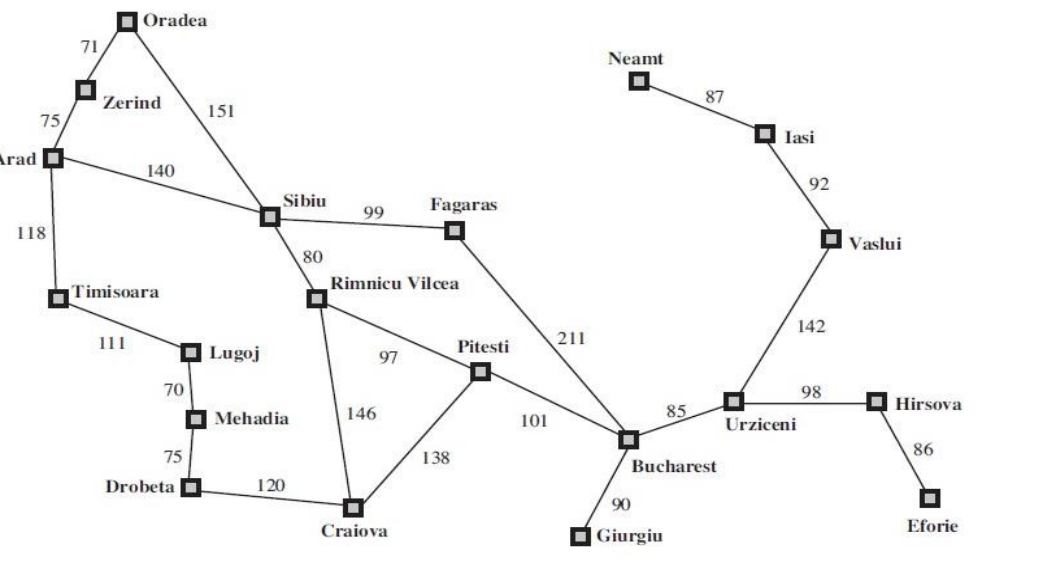

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
